# ML Assignment 2 — Dry Bean Classification

This notebook is designed for the assignment requirements:

- Dataset: **Dry Bean Dataset**
- Classification models:
  1. Logistic Regression
  2. Decision Tree
  3. K-Nearest Neighbors (KNN)
  4. Gaussian Naive Bayes
  5. Random Forest
- Evaluation metrics for each model:
  - Accuracy
  - AUC
  - Precision
  - Recall
  - F1 Score
  - Matthews Correlation Coefficient (MCC)

> Place `Dry_Bean_Dataset.xlsx` in the same folder as this notebook before running it.


## 1. Import required libraries

If a package is missing in your environment, install it before continuing.  
For Excel support, `openpyxl` may be required.


In [3]:
!pip install openpyxl

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Load the Dry Bean dataset

In [5]:
DATA_FILE = "Dry_Bean_Dataset.xlsx"

if not os.path.exists(DATA_FILE):
    raise FileNotFoundError(
        f"{DATA_FILE} was not found. "
        "Place the Excel file in the same folder as this notebook."
    )

df = pd.read_excel(DATA_FILE)
print("Dataset loaded successfully!")


Dataset loaded successfully!


## 3. Inspect the dataset

In [7]:
print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [9]:
print("Total missing values:", df.isnull().sum().sum())
print("\nMissing values by column:")
display(df.isnull().sum().to_frame("Missing Values"))


Total missing values: 0

Missing values by column:


,Missing Values
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [10]:
print("Number of classes:", df["Class"].nunique())
print("\nClass distribution:")
display(df["Class"].value_counts().to_frame("Count"))


Number of classes: 7

Class distribution:


,Count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


In [11]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)


Number of duplicate rows: 68


## 4. Data cleaning

Duplicate records can cause the same observation to appear more than once and may bias model evaluation.  
This notebook removes exact duplicate rows before the train/test split.

If your instructor asks you to preserve duplicates, comment out the `drop_duplicates()` line.


In [13]:
rows_before = len(df)

df = df.drop_duplicates().reset_index(drop=True)

rows_after = len(df)

print("Rows before duplicate removal:", rows_before)
print("Rows after duplicate removal :", rows_after)
print("Duplicates removed           :", rows_before - rows_after)


Rows before duplicate removal: 13611
Rows after duplicate removal : 13543
Duplicates removed           : 68


## 5. Separate input features and target

In [15]:
X = df.drop(columns=["Class"])
y = df["Class"]

print("Number of input features:", X.shape[1])
print("Target column:", y.name)
print("Target classes:", sorted(y.unique()))


Number of input features: 16
Target column: Class
Target classes: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']


## 6. Create a stratified train/test split

- 80% training data
- 20% test data
- `random_state=42` makes the split reproducible.
- `stratify=y` helps preserve the class proportions in both sets.


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Test samples    :", X_test.shape[0])


Training samples: 10834
Test samples    : 2709


## 7. Define the five required models

`StandardScaler` is used inside the pipelines for Logistic Regression and KNN because these models are sensitive to feature scale.

Decision Tree, Gaussian Naive Bayes, and Random Forest are trained on the original feature values.


In [19]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=5))
    ]),

    "Naive Bayes": GaussianNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )
}

print("Models defined:")
for name in models:
    print("-", name)


Models defined:
- Logistic Regression
- Decision Tree
- KNN
- Naive Bayes
- Random Forest


## 8. Train and evaluate all five models

For multiclass classification:

- Precision, Recall, and F1 use **weighted averaging**.
- AUC uses **One-vs-Rest (OvR)** with weighted averaging.
- MCC supports multiclass classification directly.


In [21]:
results = []

for model_name, model in models.items():
    print(f"Training {model_name}...")

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # The order of probability columns follows model.classes_
    auc = roc_auc_score(
        y_test,
        y_prob,
        multi_class="ovr",
        average="weighted",
        labels=model.classes_
    )

    results.append({
        "ML Model Name": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": auc,
        "Precision": precision_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "Recall": recall_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "F1": f1_score(
            y_test, y_pred, average="weighted", zero_division=0
        ),
        "MCC": matthews_corrcoef(y_test, y_pred)
    })

print("Training and evaluation completed.")


Training Logistic Regression...
Training Decision Tree...
Training KNN...
Training Naive Bayes...
Training Random Forest...
Training and evaluation completed.


## 9. Model comparison table

In [23]:
results_df = pd.DataFrame(results)

metric_columns = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]
results_df[metric_columns] = results_df[metric_columns].round(4)

display(results_df)


,ML Model Name,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.9192,0.9934,0.9197,0.9192,0.9193,0.9023
1,Decision Tree,0.8955,0.9357,0.8954,0.8955,0.8953,0.8737
2,KNN,0.9155,0.9811,0.9163,0.9155,0.9157,0.8978
3,Naive Bayes,0.7630,0.9644,0.7647,0.7630,0.7607,0.7143
4,Random Forest,0.9192,0.9919,0.9192,0.9192,0.9191,0.9022


In [24]:
best_model_name = results_df.loc[results_df["F1"].idxmax(), "ML Model Name"]
print("Best model based on weighted F1 Score:", best_model_name)


Best model based on weighted F1 Score: Logistic Regression


## 10. Detailed report for each model

This section prints the classification report for each trained model.


In [26]:
for model_name, model in models.items():
    print("=" * 80)
    print(model_name)
    print("=" * 80)

    y_pred = model.predict(X_test)
    print(classification_report(y_test, y_pred, zero_division=0))


Logistic Regression
              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709

Decision Tree
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.89      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.89      0.91      0.90       326
    DERMASON       0.89      0.90      0.89       709
       HOROZ       0.95      0.92      0.94       372
       SEKER       0.91      0.94      0.92 

## 11. Confusion matrix for each model

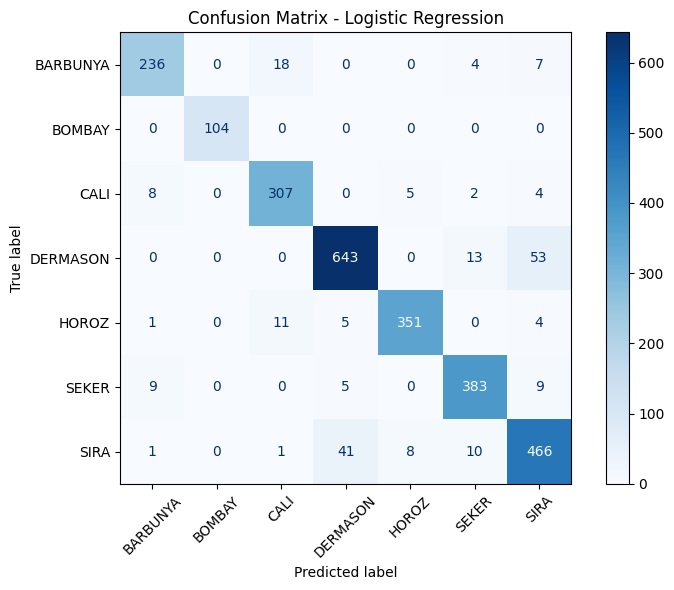

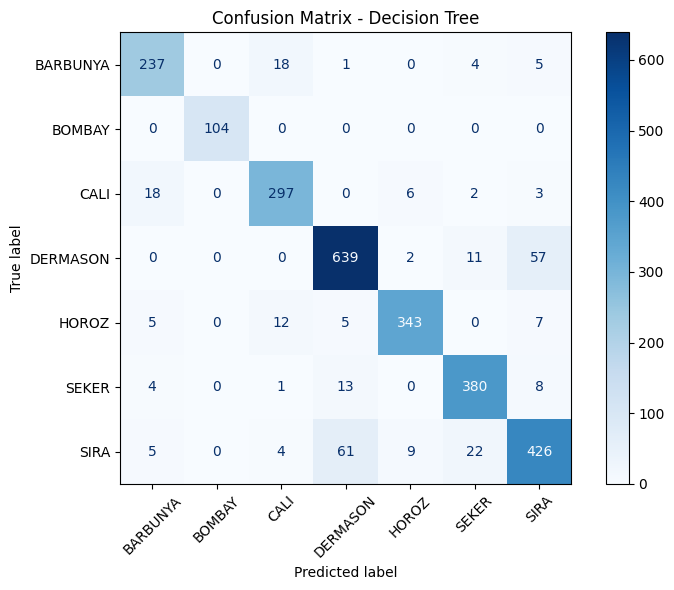

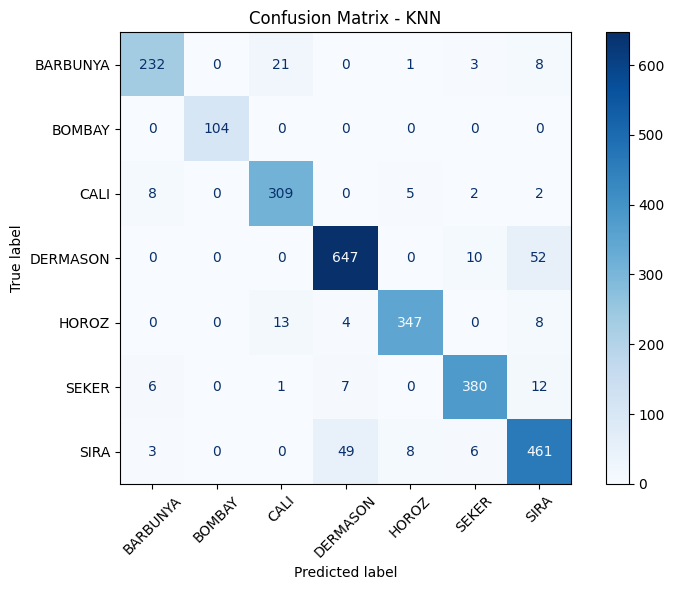

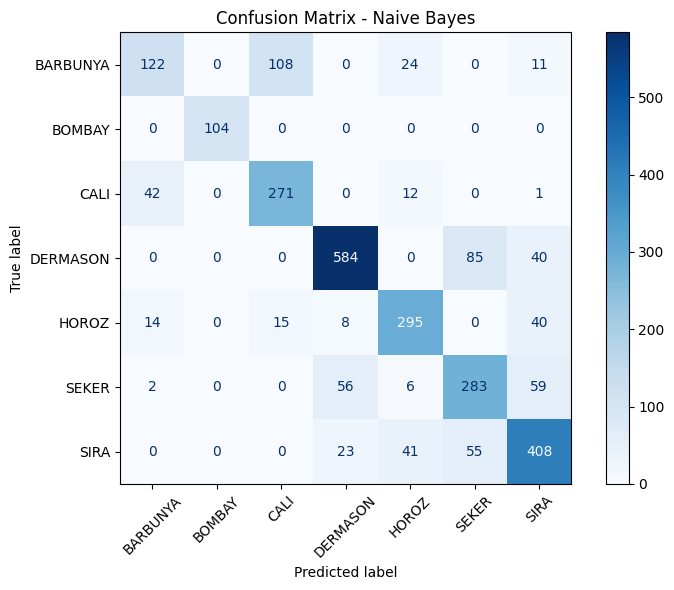

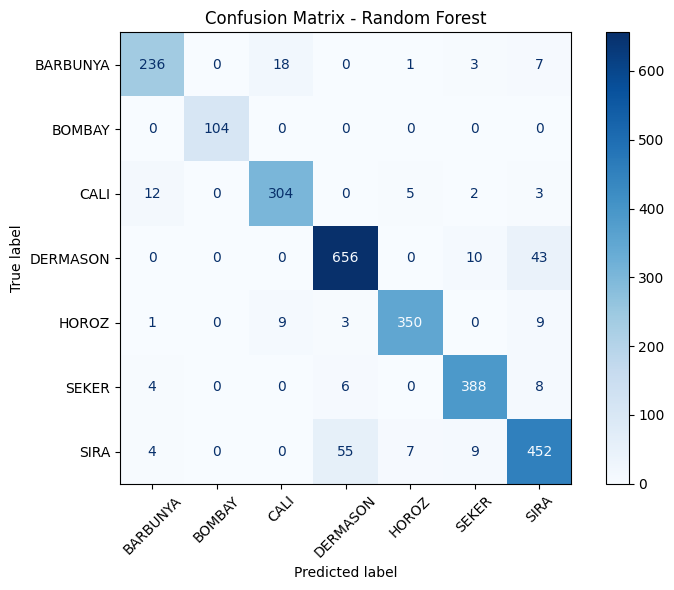

In [28]:
for model_name, model in models.items():
    y_pred = model.predict(X_test)

    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        xticks_rotation=45,
        cmap="Blues",
        ax=ax
    )
    ax.set_title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()


## 12. Save test data

The Streamlit app can use this held-out test set for model evaluation.  
The true `Class` label is included so the app can calculate metrics and display a confusion matrix.


In [30]:
test_data = X_test.copy()
test_data["Class"] = y_test.values

test_data.to_csv("test_data.csv", index=False)

print("Saved: test_data.csv")
print("Shape:", test_data.shape)
display(test_data.head())


Saved: test_data.csv
Shape: (2709, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
1223,40512,737.636,248.202030,208.525152,1.190274,0.542365,40973,227.115566,0.744268,0.988749,0.935641,0.915043,0.006127,0.002650,0.837304,0.996621,SEKER
11769,31890,660.655,250.417300,162.522502,1.540816,0.760783,32240,201.503372,0.801962,0.989144,0.918153,0.804670,0.007853,0.002031,0.647494,0.997670,DERMASON
12059,33107,671.869,244.728317,172.938116,1.415121,0.707560,33506,205.312303,0.798683,0.988092,0.921638,0.838940,0.007392,0.002259,0.703820,0.995990,DERMASON
7126,61684,984.878,412.115648,191.473280,2.152340,0.885515,62303,280.247227,0.784724,0.990065,0.799130,0.680021,0.006681,0.000881,0.462428,0.995303,HOROZ
638,37189,700.253,243.343401,194.910062,1.248491,0.598708,37534,217.601713,0.784826,0.990808,0.953047,0.894217,0.006543,0.002581,0.799623,0.998322,SEKER


## 13. Save trained models

In [32]:
os.makedirs("model", exist_ok=True)

model_filenames = {
    "Logistic Regression": "logistic_regression.pkl",
    "Decision Tree": "decision_tree.pkl",
    "KNN": "knn.pkl",
    "Naive Bayes": "naive_bayes.pkl",
    "Random Forest": "random_forest.pkl"
}

for model_name, filename in model_filenames.items():
    path = os.path.join("model", filename)
    joblib.dump(models[model_name], path)
    print("Saved:", path)


Saved: model/logistic_regression.pkl
Saved: model/decision_tree.pkl
Saved: model/knn.pkl
Saved: model/naive_bayes.pkl
Saved: model/random_forest.pkl


## 14. Save comparison results

In [34]:
results_df.to_csv("model_comparison.csv", index=False)
print("Saved: model_comparison.csv")


Saved: model_comparison.csv


## 15. Observations — complete after running the models

Use your actual results from the comparison table above. Do **not** copy generic observations without checking the measured values.

| Model | Observation |
|---|---|
| Logistic Regression | Add your observation based on Accuracy, AUC, Precision, Recall, F1 and MCC. |
| Decision Tree | Add your observation based on the measured results. |
| KNN | Add your observation based on the measured results. |
| Naive Bayes | Add your observation based on the measured results. |
| Random Forest | Add your observation based on the measured results. |
| Overall Winner | Select the model that performs best overall and explain why. |

When we have your actual output, we can write these observations together.
